# Capacità degli stabilimenti vs. Rendimento: analisi di portafoglio bidimensionale con PROC SGPLOT

## Sintesi esecutiva

Un portafoglio di produzione manifatturiera discreta ha due numeri che contano per ogni linea di prodotto contemporaneamente: **quanta capacità macchina consuma** e **quanto output buono consegna effettivamente**. Un grafico a barre monodimensionale può mostrarne solo uno. Questo notebook visualizza entrambi insieme con `PROC SGPLOT`, usando un **grafico a bolle** come vista principale — ogni linea è posizionata per capacità (x) e rendimento (y), con la dimensione della bolla che codifica il suo tasso di produttività (unità per ora macchina). Le linee che si trovano in basso a destra (molta capacità, poco output) sono pozzi di capacità; le linee in alto a sinistra con una bolla grande sono ad alta resa. Una vista a barre raggruppate scompone poi il rendimento per stabilimento, e una classifica di produttività conferma il divario.

Lavorando sull'output realmente eseguito (otto linee di prodotto su tre stabilimenti, 100 turni aggregati in 24 celle linea-stabilimento), l'analisi rileva che **Fusione** è il più chiaro pozzo di capacità del portafoglio (14.3 unità buone per ora macchina — assorbe il 10.1% della capacità totale ma consegna solo il 3.2% delle unità buone), mentre **Imballaggio** è la linea ad alta resa per eccellenza (119.2 unità per ora — il 9.1% della capacità restituisce il 23.8% dell'output). Tra gli stabilimenti, **Stuttgart** corre più veloce a 49.9 unità/ora e **Monterrey** più lento a 41.6.

## Fonti dei dati

| Fonte | Descrizione | Record |
|--------|-------------|--------|
| WORK.PRODUCTION_RUNS | Turni di produzione sintetici su 8 linee di prodotto, 3 stabilimenti e 3 turni — ore macchina pianificate, ore di esercizio, fermi macchina, unità lorde/di scarto/buone (limitato a 100 osservazioni in modalità senza licenza) | 100 |
| WORK.LINE_CAPACITY | Riepilogo aggregato per linea di prodotto e stabilimento: ore di capacità totali (x), unità buone prodotte (y), e % di resa delle unità accettate | 24 |

*Tutti i dati sono sintetici e generati nel notebook con un seed fisso — nessun file esterno, nessuna rete.*

# Analisi capacità degli stabilimenti vs. rendimento

**Dominio:** Manifattura discreta — operations / ingegneria industriale

**Procedura:** `PROC SGPLOT` (ODS Statistical Graphics)

Un grafico a barre convenzionale mostra una singola risposta per categoria. Per confrontare un portafoglio di produzione su **due** dimensioni numeriche contemporaneamente — *quanta capacità consuma ogni linea di prodotto* rispetto a *quanto output consegna effettivamente* — serve un grafico che collochi entrambe sulla stessa tela. L'istruzione `BUBBLE` di `PROC SGPLOT` fa esattamente questo: posiziona ogni linea per capacità (x) e unità buone (y) e lascia che una terza misura, il tasso di produttività, guidi la dimensione della bolla. Una linea che si trova molto a destra ma in basso è un pozzo di capacità; una linea in alto a sinistra con una bolla grande è una linea ad alta resa da proteggere. Questo notebook costruisce un dataset di produzione sintetico realistico e guida SGPLOT attraverso un grafico a bolle, un grafico a barre raggruppato per stabilimento, un'analisi di dettaglio a stabilimento singolo e un confronto tra stabilimenti con barre affiancate raggruppate.

> **Una nota su PROC GAREABAR.** Il modo classico di SAS/GRAPH per codificare due dimensioni per *barra* è `PROC GAREABAR` (un grafico area-barra solo ActiveX in cui la larghezza della barra codifica una variabile e l'altezza un'altra). GAREABAR **non è ancora implementata in questa build di Jenner** — la lacuna è tracciata dal test archiviato `tests/400996_nb_gareabar_unimplemented`. Questo notebook raggiunge lo stesso obiettivo analitico con `PROC SGPLOT`, pienamente supportata, le cui viste a bolle e a barre raggruppate trasmettono la stessa storia di capacità-vs-rendimento.

## 1. Generare dati di produzione sintetici

Simuliamo sei settimane di turni di produzione per una rete manifatturiera discreta a tre stabilimenti. Ogni linea di prodotto ha un tempo di ciclo di base e un tasso di scarto; il rendimento è guidato dalle ore macchina pianificate, dall'efficienza specifica della linea e da fermi macchina casuali. `call streaminit` fissa il seed così che il notebook sia completamente riproducibile — nessun file esterno, nessuna rete.

In [1]:
/* --------------------------------------------------------
   Turni di produzione sintetici a livello di turno
   8 linee di prodotto x 3 stabilimenti x 3 turni x ~10 giorni
   variabile larghezza = ore macchina pianificate (capacita)
   risposta            = unita buone prodotte (rendimento)
   -------------------------------------------------------- */
DATI work.production_runs;
    CHIAMARE streaminit(20260531);
    LUNGHEZZA product_line $18 plant $12 shift $12;

    VETTORE line_names[8] $18 _temporary_
        ('Stampaggio'  'Saldatura'   'Lavorazione' 'Fusione'
         'Iniezione' 'Assemblaggio'  'Finitura' 'Imballaggio');
    /* unita nominali prodotte per ora macchina, per linea */
    VETTORE line_rate[8] _temporary_
        (42 28 35 18 60 75 90 140);
    /* frazione di scarto di base per linea */
    VETTORE line_scrap[8] _temporary_
        (0.04 0.06 0.05 0.09 0.03 0.02 0.02 0.01);
    VETTORE plant_names[3] $12 _temporary_
        ('Detroit' 'Monterrey' 'Stuttgart');
    /* moltiplicatore di efficienza per stabilimento */
    VETTORE plant_eff[3] _temporary_ (1.00 0.92 1.08);
    VETTORE shift_names[3] $12 _temporary_ ('Giorno' 'Pomeriggio' 'Notte');
    VETTORE shift_eff[3] _temporary_ (1.00 0.95 0.88);

    FARE day = 1 FINO_A 10;
        FARE li = 1 FINO_A 8;
            FARE pi = 1 FINO_A 3;
                FARE si = 1 FINO_A 3;
                    product_line = line_names[li];
                    plant        = plant_names[pi];
                    shift        = shift_names[si];

                    /* ore macchina pianificate per il turno */
                    sched_hours = round(6.5 + rand('uniform') * 1.5, 0.1);

                    /* i fermi macchina non pianificati riducono la capacita */
                    downtime_hours =
                        round(rand('uniform') * 1.2
                              * (2 - plant_eff[pi]), 0.1);
                    run_hours = MAX(sched_hours - downtime_hours, 0.5);

                    /* tasso di rendimento effettivo con rumore */
                    eff = plant_eff[pi] * shift_eff[si]
                          * (0.9 + rand('uniform') * 0.2);
                    gross_units =
                        round(run_hours * line_rate[li] * eff);

                    scrap_rate = line_scrap[li]
                                 * (0.7 + rand('uniform') * 0.6);
                    scrap_units = round(gross_units * scrap_rate);
                    good_units  = gross_units - scrap_units;

                    run_date = '05JAN2026'd + (day - 1);
                    USCITA;
                FINE;
            FINE;
        FINE;
    FINE;
    MANTENERE run_date product_line plant shift
         sched_hours run_hours downtime_hours
         gross_units scrap_units good_units;
    FORMATO run_date date9.;
ESEGUIRE;

PROCEDURA STAMPARE DATI=work.production_runs(obs=8) noobs ETICHETTA;
    TITOLO "Esempio di turni di produzione sintetici a livello di turno";
    ETICHETTA run_date="Data" product_line="Linea di prodotto" plant="Stabilimento"
          shift="Turno" sched_hours="Ore pianificate" run_hours="Ore di esercizio"
          downtime_hours="Fermi macchina (ore)" gross_units="Unita lorde"
          scrap_units="Unita di scarto" good_units="Unita buone";
ESEGUIRE;
TITOLO;


                              Esempio di turni di produzione sintetici a livello di turno                               

     Data  Linea di prodotto  Stabilimento       Turno  Ore pianificate  Ore di esercizio  Fermi macchina (ore)  Unita lorde  Unita di scarto  Unita buone
05JAN2026  Stampaggio         Detroit       Giorno                  7.8               6.7                   1.1          306               14          292
05JAN2026  Stampaggio         Detroit       Pomeriggio              6.8               6.5                   0.3          259               12          247
05JAN2026  Stampaggio         Detroit       Notte                     8               7.6                   0.4          269               11          258
05JAN2026  Stampaggio         Monterrey     Giorno                  7.9               6.8                   1.1          283               12          271
05JAN2026  Stampaggio         Monterrey     Pomeriggio              7.5               6.9              


NOTE: DATA work.production_runs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.production_runs (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.16 seconds
  cpu   0.16 seconds
NOTE: PROC PRINT data=work.production_runs

NOTE: PROC PRINT completed: 8 observations printed, 10 variables


## 2. Aggregare a livello linea-stabilimento

I grafici confrontano un punto per categoria, quindi aggreghiamo il dettaglio a livello di turno in un riepilogo per linea di prodotto e stabilimento. `total_capacity` (somma delle ore macchina pianificate) diventa la dimensione **x**, `good_units` (somma dell'output accettato) la dimensione **y**, e `units_per_hr` (unità buone ÷ ore di capacità) il tasso di produttività che dimensionerà le bolle. Manteniamo `plant` così può servire come variabile di raggruppamento più avanti. Costruiamo anche un riepilogo a livello di linea (su tutti gli stabilimenti) per il grafico a bolle del portafoglio.

In [2]:
/* --------------------------------------------------------
   Aggregazione a livello product_line x plant
   total_capacity -> x (ore di capacita)
   good_units     -> y (rendimento)
   units_per_hr   -> dimensione bolla (produttivita)
   -------------------------------------------------------- */
PROCEDURA MEDIE DATI=work.production_runs NOPRINT NWAY;
    CLASSE product_line plant;
    VARIABILE sched_hours good_units scrap_units;
    USCITA out=work.line_capacity(RIMUOVERE=_type_ _freq_)
        sum(sched_hours)  = total_capacity
        sum(good_units)   = good_units
        sum(scrap_units)  = scrap_units;
ESEGUIRE;

DATI work.line_capacity;
    IMPOSTARE work.line_capacity;
    units_per_hr = good_units / total_capacity;
    yield_pct    = 100 * good_units / (good_units + scrap_units);
    FORMATO units_per_hr 6.1 yield_pct 5.1;
ESEGUIRE;

PROCEDURA ORDINARE DATI=work.line_capacity;
    PER product_line plant;
ESEGUIRE;

/* Riepilogo a livello di linea (su tutti gli stabilimenti) per la vista di portafoglio */
PROCEDURA MEDIE DATI=work.line_capacity NOPRINT NWAY;
    CLASSE product_line;
    VARIABILE total_capacity good_units;
    USCITA out=work.line_total(RIMUOVERE=_type_ _freq_)
        sum(total_capacity) = total_capacity
        sum(good_units)     = good_units;
ESEGUIRE;

DATI work.line_total;
    IMPOSTARE work.line_total;
    units_per_hr = good_units / total_capacity;
    FORMATO units_per_hr 6.1;
ESEGUIRE;

PROCEDURA ORDINARE DATI=work.line_total;
    PER units_per_hr;
ESEGUIRE;

PROCEDURA STAMPARE DATI=work.line_total noobs ETICHETTA;
    VARIABILE product_line total_capacity good_units units_per_hr;
    ETICHETTA product_line="Linea di prodotto" total_capacity="Capacità totale (ore)"
          good_units="Unità buone" units_per_hr="Unità per ora";
    TITOLO "Linee del portfolio classificate per produttività (unità buone per ora macchina)";
ESEGUIRE;
TITOLO;


                    Linee del portfolio classificate per produttività (unità buone per ora macchina)                    

Linea di prodotto   Capacità totale (ore)   Unità buone   Unità per ora
Fusione                              73.4          1050            14.3
Saldatura                           130.8          3038            23.2
Lavorazione                         128.9          3762            29.2
Stampaggio                          130.7          4713            36.1
Iniezione                            66.2          3430            51.8
Assemblaggio                         67.3          4289            63.7
Finitura                             64.6          4927            76.3
Imballaggio                          65.9          7855           119.2




NOTE: PROC MEANS
NOTE: Output dataset work.line_capacity has 24 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_capacity


NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_capacity

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.line_total has 8 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_total


NOTE: Read 8 rows from work.line_total.
NOTE: Wrote work.line_total (8 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_total

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 8 rows from work.line_total.
NOTE: Wrote 

## 3. Aprire la destinazione ODS Graphics

`PROC SGPLOT` esegue il rendering tramite ODS Statistical Graphics. Apriamo una destinazione `ODS HTML` così che ogni grafico sia emesso come immagine, e attiviamo `ODS GRAPHICS ON`. Non serve alcun driver di dispositivo speciale — SGPLOT è indipendente dal dispositivo, a differenza delle procedure SAS/GRAPH solo ActiveX.

In [3]:
ODS html;
ODS GRAPHICS ON;



NOTE: ODS HTML: Destination opened.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).


## 4. Grafico a bolle del portafoglio — capacità vs. rendimento

La vista principale: `BUBBLE x=total_capacity y=good_units size=units_per_hr`. Ogni linea di prodotto è una bolla, posizionata per ore di capacità totali (x) e unità buone totali (y), con l'area della bolla scalata sul suo tasso di produttività. `DATALABEL=` stampa il nome della linea accanto a ogni bolla. Questo è il confronto bidimensionale che un plant manager desidera — i pozzi di capacità cadono in **basso a destra** (molte ore, poco output, bolla piccola); le linee ad alta resa salgono in **alto a sinistra** (poche ore, molto output, bolla grande).

                                   Portfolio di produzione - Capacità vs. Rendimento                                    
                    x = ore macchina pianificate; y = unità buone; dimensione bolla = unità per ora                     


In basso a destra = pozzo di capacità; in alto a sinistra con bolla grande = linea ad alta resa.



NOTE: Option TITLE changed to Portfolio di produzione - Capacità vs. Rendimento.
NOTE: Option TITLE2 changed to x = ore macchina pianificate; y = unità buone; dimensione bolla = unità per ora.
NOTE: Option FOOTNOTE changed to In basso a destra = pozzo di capacità; in alto a sinistra con bolla grande = linea ad alta resa..
NOTE: PROC SGPLOT data=work.line_total

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


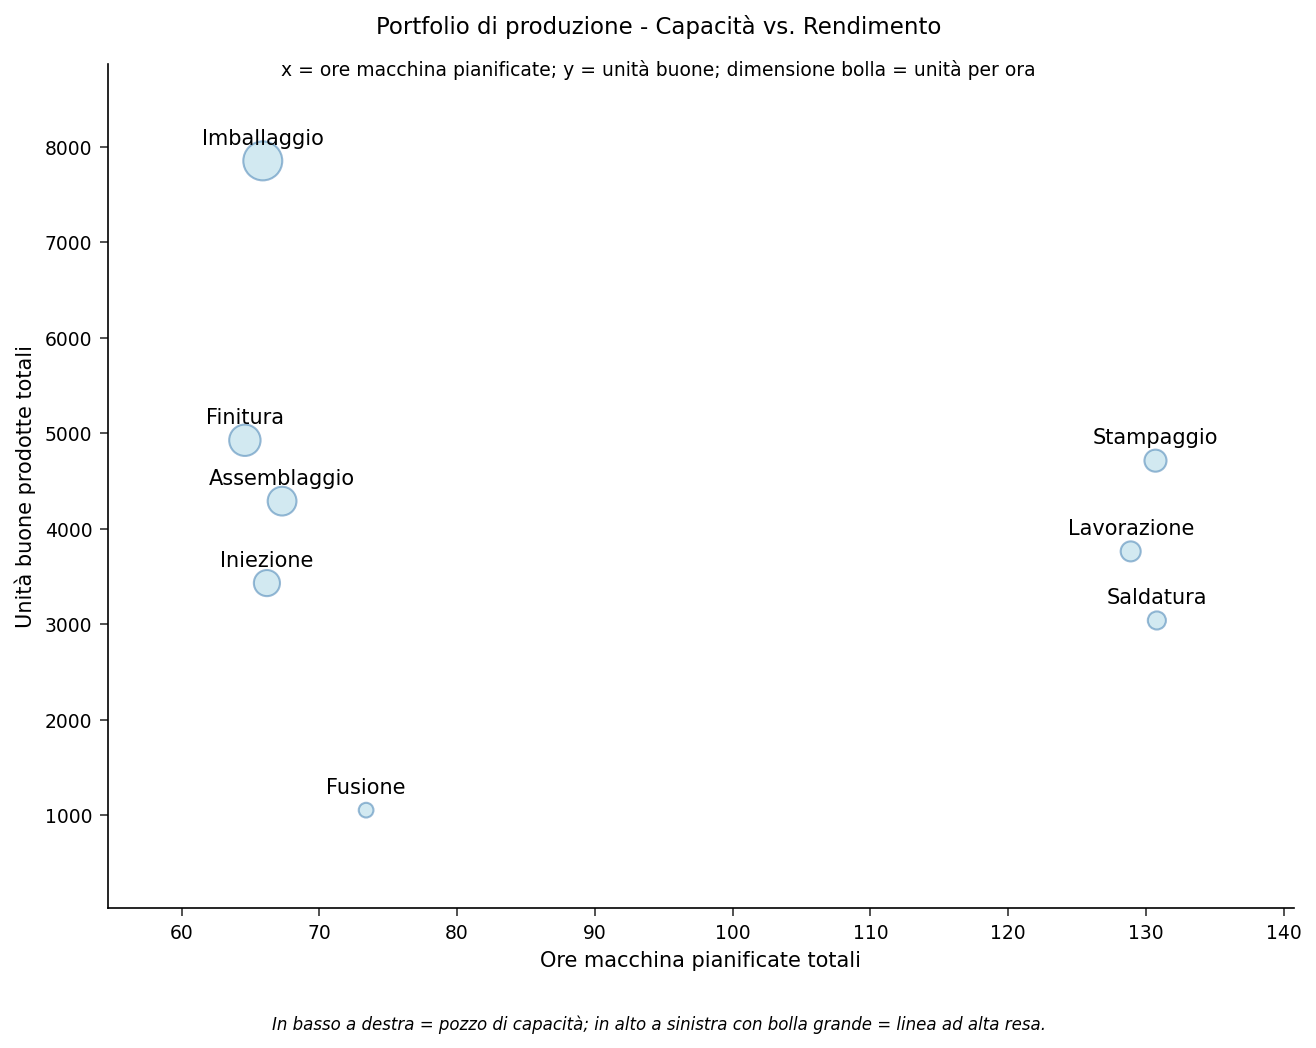

In [4]:
TITOLO "Portfolio di produzione - Capacità vs. Rendimento";
title2 "x = ore macchina pianificate; y = unità buone; dimensione bolla = unità per ora";
footnote JUSTIFY=LEFT
    "In basso a destra = pozzo di capacità; in alto a sinistra con bolla grande = linea ad alta resa.";

PROCEDURA SGPLOT DATI=work.line_total;
    bubble x=total_capacity y=good_units size=units_per_hr /
        DATALABEL=product_line
        fillattrs=(color=cx2C5F8A)
        TRANSPARENCY=0.45;
    XAXIS ETICHETTA="Ore macchina pianificate totali";
    YAXIS ETICHETTA="Unità buone prodotte totali";
ESEGUIRE;

TITOLO; title2; footnote;


## 5. Rendimento per linea, scomposto per stabilimento

Per vedere come l'output di ogni linea si suddivide tra i tre stabilimenti, un grafico `VBAR product_line / response=good_units group=plant` impila i contributi degli stabilimenti all'interno di ogni barra. Questa è la vista di segmentazione: mostra sia l'altezza totale (unità buone per linea) sia il mix di stabilimenti all'interno di ogni barra, così puoi individuare le linee in cui uno stabilimento domina l'output.

                              Unità buone per linea di prodotto, impilate per stabilimento                              
                       Altezza barra = unità buone totali; segmenti = contributo per stabilimento                       




NOTE: Option TITLE changed to Unità buone per linea di prodotto, impilate per stabilimento.
NOTE: Option TITLE2 changed to Altezza barra = unità buone totali; segmenti = contributo per stabilimento.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


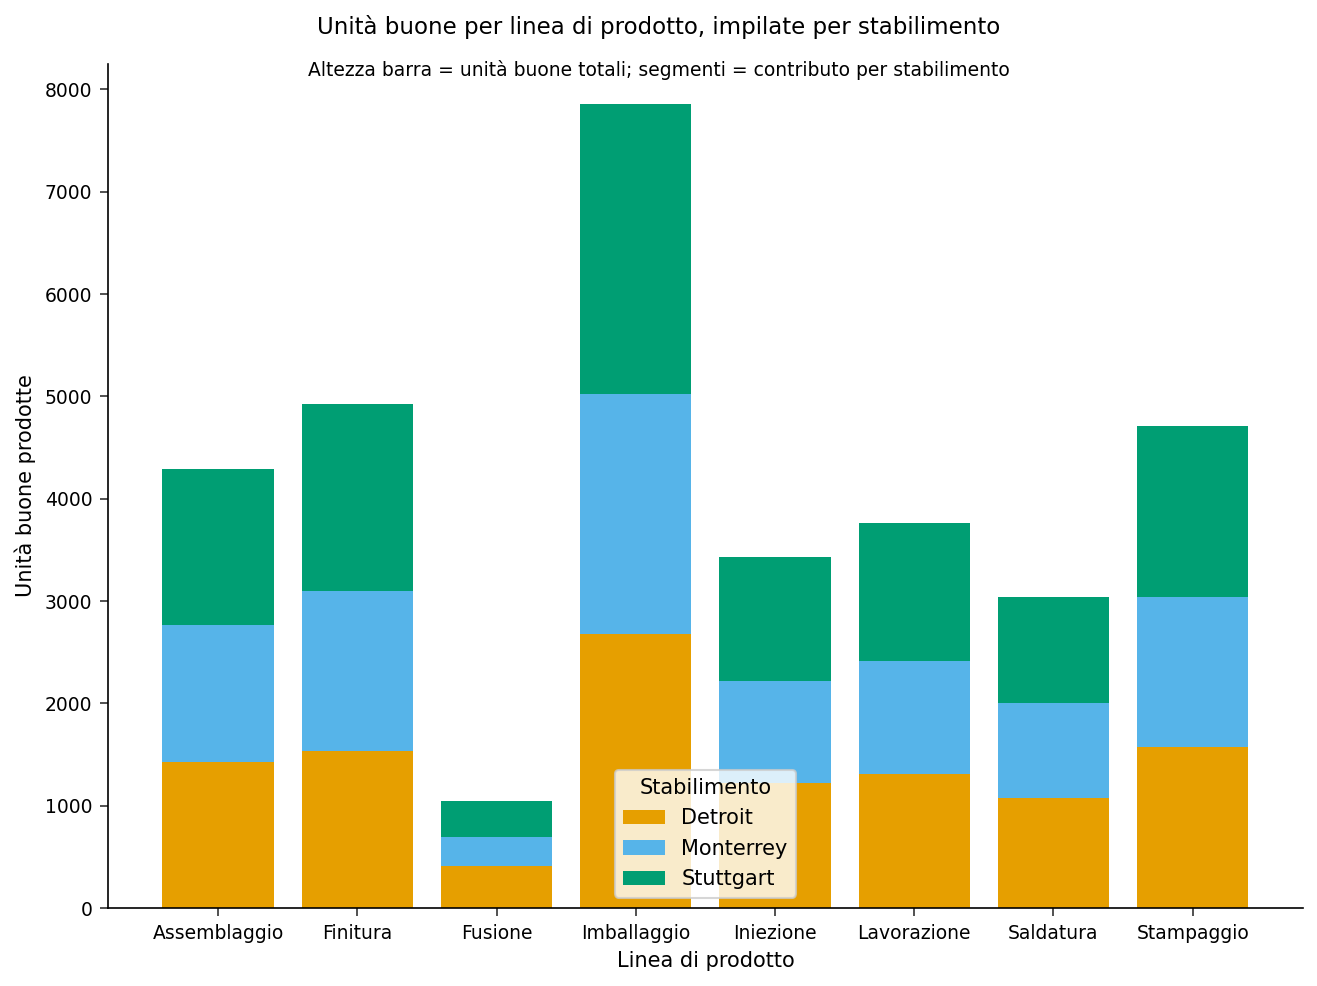

In [5]:
TITOLO "Unità buone per linea di prodotto, impilate per stabilimento";
title2 "Altezza barra = unità buone totali; segmenti = contributo per stabilimento";

PROCEDURA SGPLOT DATI=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUP=plant
        GROUPDISPLAY=stack;
    XAXIS ETICHETTA="Linea di prodotto" fitpolicy=ROTATE;
    YAXIS ETICHETTA="Unità buone prodotte";
    keylegend / TITOLO="Stabilimento" position=bottom;
ESEGUIRE;

TITOLO; title2;


## 6. Analisi di dettaglio della produttività di un singolo stabilimento (WHERE)

Le barre orizzontali (`HBAR`) si adattano bene a etichette di linea di prodotto lunghe. Una clausola `WHERE` filtra sullo stabilimento di Stuttgart, e le barre sono disegnate per `units_per_hr` così il grafico classifica le linee di Stuttgart per produttività. Poiché l'input è ordinato in modo crescente per tasso, la linea meno produttiva si trova in basso e quella più produttiva in alto.

                            Stabilimento di Stuttgart - Linee classificate per produttività                             


Lunghezza barra = unità buone per ora macchina (analisi di dettaglio di un singolo stabilimento).



NOTE: Option TITLE changed to Stabilimento di Stuttgart - Linee classificate per produttività.
NOTE: Option FOOTNOTE changed to Lunghezza barra = unità buone per ora macchina (analisi di dettaglio di un singolo stabilimento)..
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


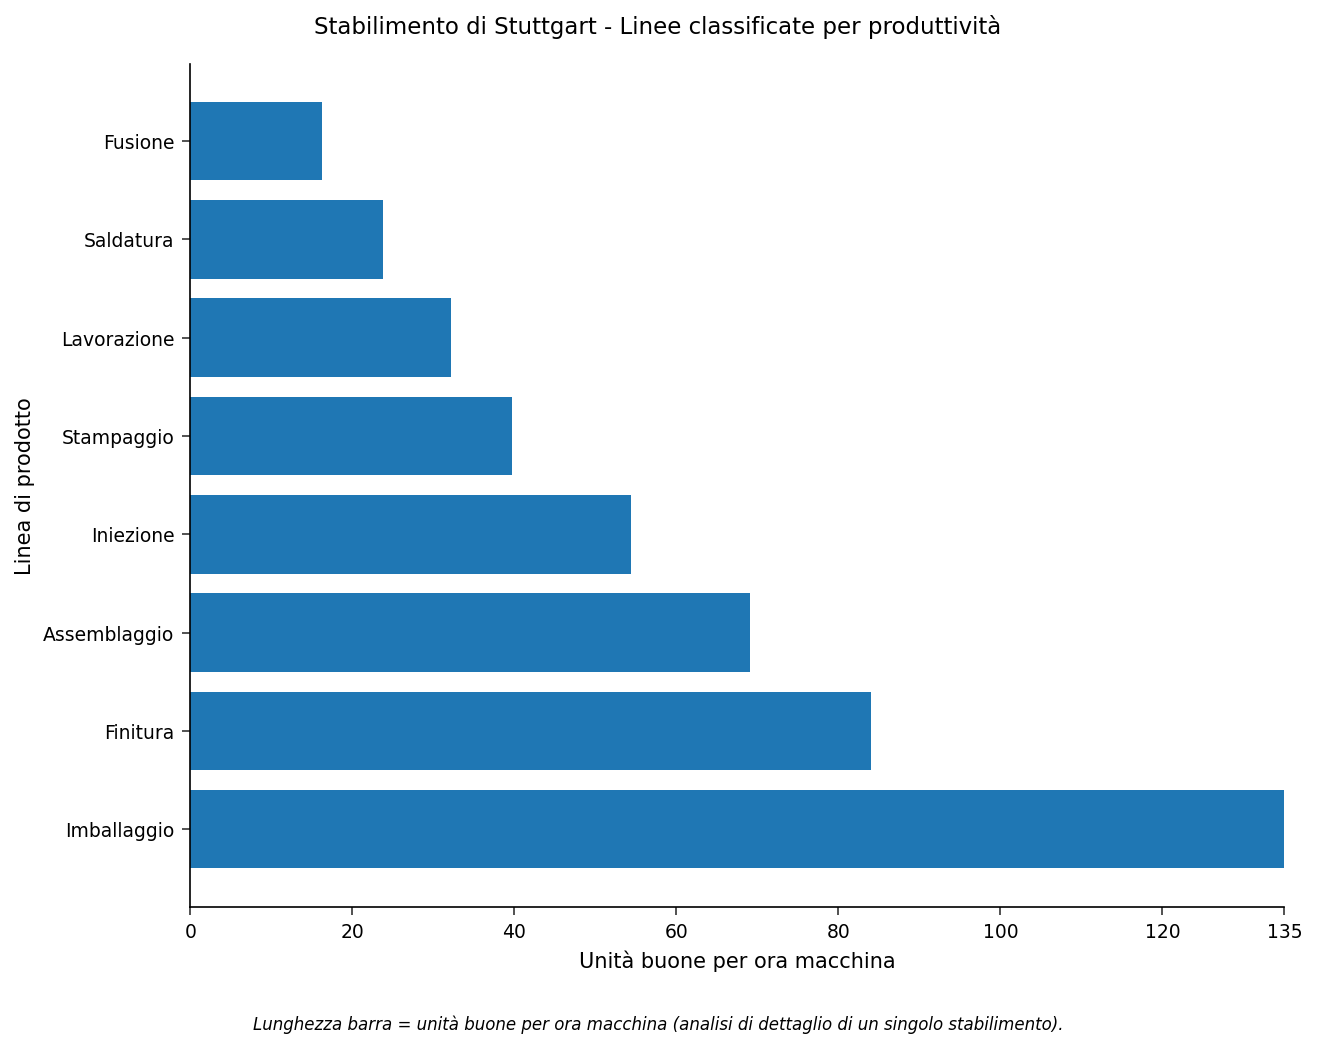

In [6]:
TITOLO "Stabilimento di Stuttgart - Linee classificate per produttività";
footnote JUSTIFY=LEFT "Lunghezza barra = unità buone per ora macchina (analisi di dettaglio di un singolo stabilimento).";

PROCEDURA SGPLOT DATI=work.line_capacity;
    DOVE plant = 'Stuttgart';
    HBAR product_line / RESPONSE=units_per_hr
        CATEGORYORDER=respasc
        fillattrs=(color=cx28A745);
    XAXIS ETICHETTA="Unità buone per ora macchina";
    YAXIS ETICHETTA="Linea di prodotto";
ESEGUIRE;

TITOLO; footnote;


## 7. Confronto stabilimenti affiancati (barre raggruppate)

Per confrontare i tre stabilimenti linea per linea, un grafico a barre raggruppate (`GROUPDISPLAY=CLUSTER`) disegna Detroit, Monterrey e Stuttgart come barre adiacenti all'interno di ogni linea di prodotto. Questa è la vista comparativa alla pari tra stabilimenti: per ogni linea puoi leggere quale stabilimento ha prodotto più unità buone, rendendo direttamente visibili le differenze di efficienza tra stabilimenti (Stuttgart più alto, Monterrey più basso).

                                   Unità buone per linea e stabilimento - Affiancate                                    
                  Barre raggruppate: una barra per stabilimento all'interno di ogni linea di prodotto                   




NOTE: Option TITLE changed to Unità buone per linea e stabilimento - Affiancate.
NOTE: Option TITLE2 changed to Barre raggruppate: una barra per stabilimento all'interno di ogni linea di prodotto.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot3.svg
NOTE: ODS Graphics is OFF.


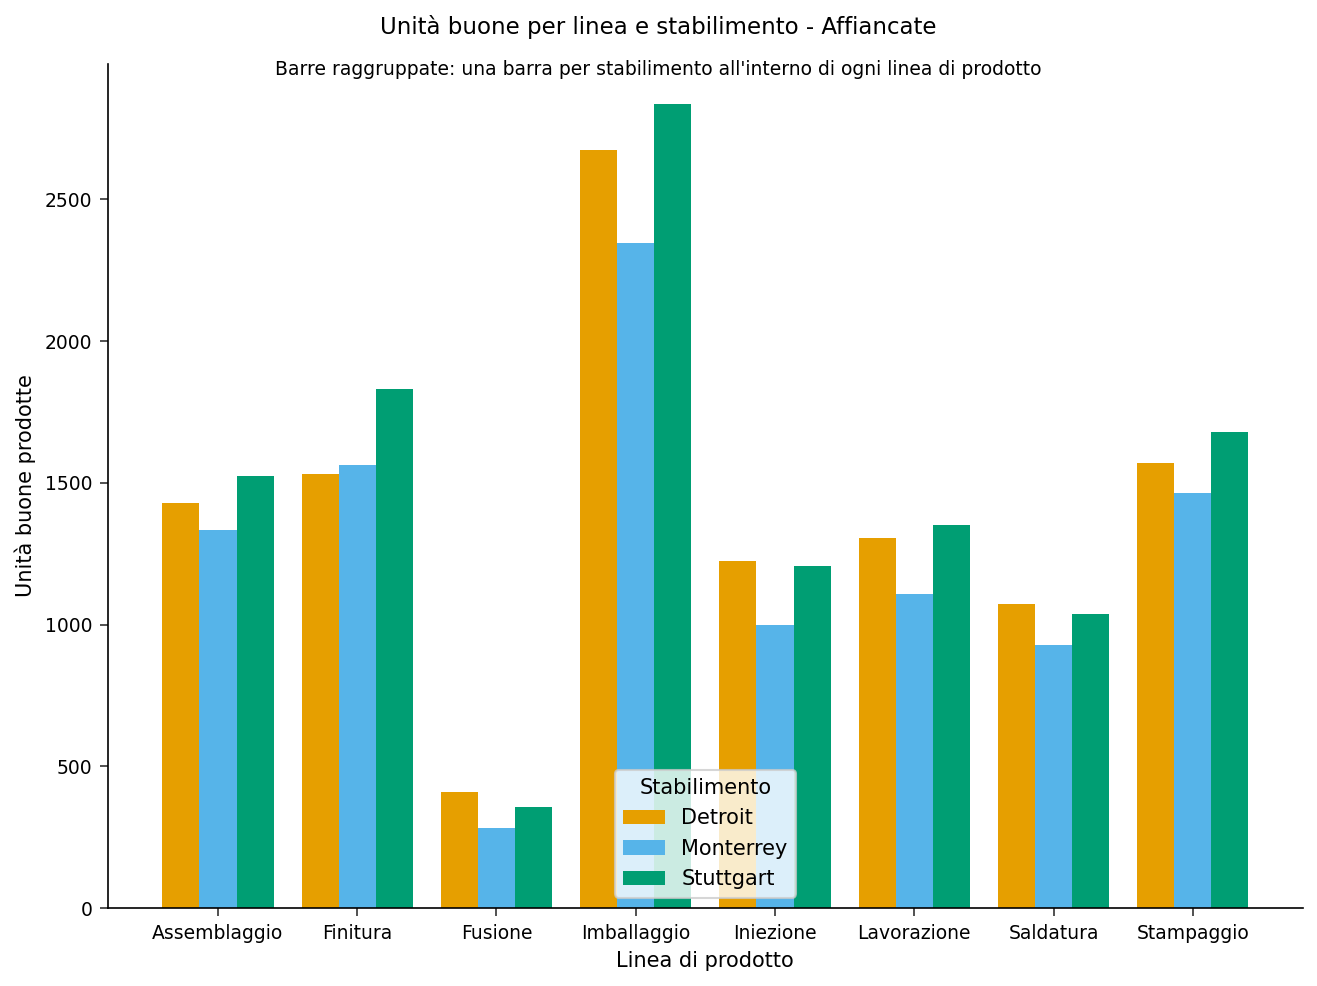

In [7]:
TITOLO "Unità buone per linea e stabilimento - Affiancate";
title2 "Barre raggruppate: una barra per stabilimento all'interno di ogni linea di prodotto";

PROCEDURA SGPLOT DATI=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUP=plant
        GROUPDISPLAY=CLUSTER;
    XAXIS ETICHETTA="Linea di prodotto" fitpolicy=ROTATE;
    YAXIS ETICHETTA="Unità buone prodotte";
    keylegend / TITOLO="Stabilimento" position=bottom;
ESEGUIRE;

TITOLO; title2;

ODS GRAPHICS OFF;
ODS html CLOSE;


## Interpretazione

Rappresentare capacità e rendimento sugli stessi assi rivela una relazione che un grafico a barre monodimensionale nasconderebbe. **Fusione** è il pozzo di capacità più evidente del portafoglio: nella classifica di produttività si trova in fondo con **14.3 unità buone per ora macchina**, e nel grafico a bolle cade in basso a sinistra come una piccola bolla — assorbe il **10.1%** delle ore pianificate totali ma restituisce solo il **3.2%** delle unità buone (porta anche la resa più bassa, ~91%, a causa della sua alta frazione di scarto). È il candidato principale per un kaizen sul tempo di ciclo e sulla riduzione degli scarti. All'estremo opposto, **Imballaggio** è la linea ad alta resa per eccellenza a **119.2 unità per ora macchina** — una bolla grande in alto sull'asse del rendimento che trasforma il **9.1%** della capacità nel **23.8%** di tutte le unità buone; proteggerne l'uptime produce un output sproporzionato. **Finitura** (76.3 unità/ora) e **Assemblaggio** (63.7) seguono lo stesso schema ad alta resa.

Lo schema è sistematico: le quattro linee a monte, lente e affamate di capacità — Fusione, Saldatura (23.2 unità/ora), Lavorazione (29.2) e Stampaggio (36.1) — consumano insieme circa il **64%** delle ore pianificate ma consegnano solo circa il **38%** delle unità buone, mentre le quattro linee veloci a valle sovra-consegnano rispetto alle ore che assorbono. La vista impilata per stabilimento e le barre raggruppate affiancate mostrano la dimensione stabilimento dietro a questo: **Stuttgart** corre più veloce a **49.9 unità buone per ora macchina**, **Detroit** è nel mezzo a **44.9**, e **Monterrey** segue a **41.6** — coerente con i fermi macchina modellati più alti di Monterrey. Dal punto di vista operativo, questo suggerisce di riequilibrare le ore pianificate verso le linee ad alta resa a valle e di confrontare i fermi macchina di Monterrey con le pratiche di Stuttgart.

*Solo dati sintetici — le cifre sono illustrative della visualizzazione bidimensionale capacità-vs-rendimento con PROC SGPLOT, non delle prestazioni reali degli stabilimenti.*